# Importing required libraries

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Loading the dataset

In [27]:
data = pd.read_csv("../Datasets/brain_stroke.csv.")
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,Male,41.0,0,0,No,Private,Rural,70.15,29.8,formerly smoked,0
4977,Male,40.0,0,0,Yes,Private,Urban,191.15,31.1,smokes,0
4978,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,31.8,smokes,0
4979,Male,40.0,0,0,Yes,Private,Rural,83.94,30.0,smokes,0


# Encoding the Columns

In [28]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])

data    

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,88,0,1,1,1,1,3769,225,1,1
1,1,101,0,1,1,1,0,2444,184,2,1
2,0,70,0,0,1,1,1,3324,203,3,1
3,0,100,1,0,1,2,0,3333,99,2,1
4,1,102,0,0,1,1,1,3386,149,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,1,62,0,0,0,1,0,576,157,1,0
4977,1,61,0,0,1,1,1,3414,170,3,0
4978,0,66,1,0,1,0,0,1947,177,3,0
4979,1,61,0,0,1,1,0,1350,159,3,0


# Splitting into X & Y

In [29]:
X = data.drop(columns = 'stroke' , axis = 1)
Y = data['stroke']

# Splitting into Training and Testing 

In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2)

# Loading the model

In [31]:
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Predictions

In [32]:
y_pred = model.predict(X_test)


# Accuracy

In [33]:
accuract = accuracy_score(y_test,y_pred)
print(f" Accuracy is :: {accuract}")
print(" Classification report")
print(classification_report(y_test,y_pred))

 Accuracy is :: 0.950852557673019
 Classification report
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       952
           1       0.00      0.00      0.00        45

    accuracy                           0.95       997
   macro avg       0.48      0.50      0.49       997
weighted avg       0.91      0.95      0.93       997



# Plotting

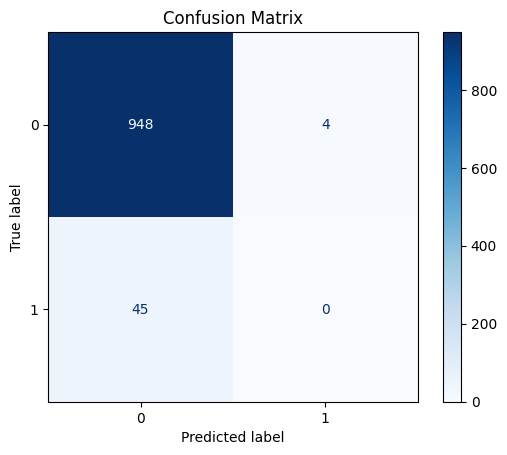

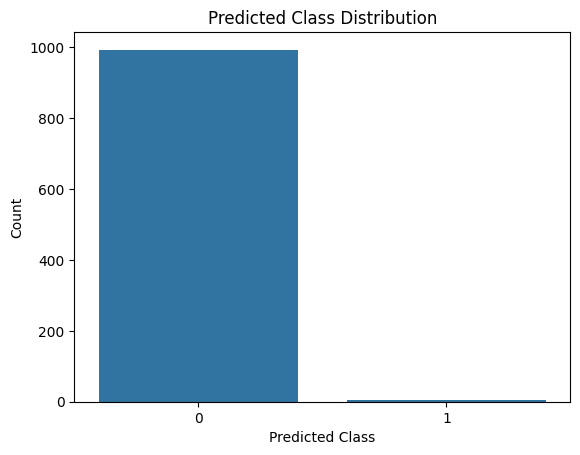

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt


# ✅ 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ✅ 2. Class-wise Prediction Distribution
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()
